In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
## load data
# Single-cell-data 
adata_pre = sc.read_h5ad('../data/frangieh/adata_preprocessed.h5ad')

# LFC data (711 rows x 2000 HVGs)
adata_lfc = sc.read_h5ad('../data/frangieh/log_fold_change_adata_hvg.h5ad')

In [3]:
# calculate basal expression profile from control cells (pertubation = control in each of the 3 conditions)
ctrl_cells = adata_pre[adata_pre.obs['perturbation'] == 'control']

df_ctrl = ctrl_cells.to_df()
df_ctrl['condition'] = ctrl_cells.obs['condition'].values

# mean basal expression per condition (3 rows x ~18.000 genes)
mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()

/tmp/ipykernel_2556/1859275621.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()


In [4]:
# create feature matrix X
# Feature 1: Basale KO-Expression for each row
basal_ko_values = []
for _, row in adata_lfc.obs.iterrows():
    cond = row['condition']
    ko_gene = row['perturbation']
    val = mean_ctrl_by_cond.loc[cond, ko_gene] if ko_gene in mean_ctrl_by_cond.columns else 0.0
    basal_ko_values.append(val)

# Feature 2: Condition One-Hot-Encoding
cond_dummies = pd.get_dummies(adata_lfc.obs['condition'], dtype=float)

# Shape: 711 rows x 4 columns
X_features = np.column_stack([basal_ko_values, cond_dummies.values])

feature_names = ['basal_ko_expression'] + list(cond_dummies.columns)

In [5]:
# scale features 
scaler = StandardScaler()
X = scaler.fit_transform(X_features)

# target matrix y: LFCs of 2000 HVGs
y = adata_lfc.X

In [6]:
# save features 
adata_lfc.obsm['X_basal'] = X
adata_lfc.uns['feature_names_basal'] = feature_names


print(f"X (Features) Shape: {X.shape}")  # expected: (711, 4)
print(f"y (Targets)  Shape: {y.shape}")  # expected: (711, 2000)
print(f"used Feature-names: {feature_names}")

X (Features) Shape: (711, 4)
y (Targets)  Shape: (711, 2000)
used Feature-names: ['basal_ko_expression', 'Co-culture', 'Control', 'IFNγ']


In [7]:
# negative control 
np.random.seed(42)
X_random_noise = np.column_stack([cond_dummies.values,np.random.normal(0, 1, size=(adata_lfc.n_obs, 50))])

# positive control 
pca_ideal = PCA(n_components=min(50, adata_lfc.n_obs, adata_lfc.n_vars), random_state=42)
target_pca = pca_ideal.fit_transform(adata_lfc.X)
X_idealized = np.column_stack([cond_dummies.values,target_pca])

adata_lfc.obsm['X_random_noise'] = StandardScaler().fit_transform(X_random_noise)
adata_lfc.obsm['X_idealized'] = StandardScaler().fit_transform(X_idealized)

In [8]:
all_results = []
conditions = ['Control', 'IFNγ', 'Co-culture']

for strategy_name, selected_50 in adata_lfc.uns['subsets'].items():
    # Filter on 50 genes and 40/10 Split
    adata_50 = adata_lfc[adata_lfc.obs['perturbation'].isin(selected_50)].copy()

    np.random.seed(42)
    test_genes_10 = np.random.choice(selected_50, size=10, replace=False).tolist()
    is_test = adata_50.obs['perturbation'].isin(test_genes_10).values

    X_50 = adata_50.obsm['X_basal']
    X_rand_50 = adata_50.obsm['X_random_noise']
    X_ideal_50 = adata_50.obsm['X_idealized']
    y_50 = adata_50.X

    X_train, X_test = X_50[~is_test], X_50[is_test]
    X_rand_train, X_rand_test = X_rand_50[~is_test], X_rand_50[is_test]
    X_ideal_train, X_ideal_test = X_ideal_50[~is_test], X_ideal_50[is_test]
    y_train, y_test = y_50[~is_test], y_50[is_test]
    obs_test = adata_50.obs[is_test].reset_index(drop=True)

    predictions = {}

    ## Baselines
    # No-Change 
    predictions['No-Change (Zeros)'] = np.zeros_like(y_test)
    
    # Dummy Train Mean
    dummy = DummyRegressor(strategy='mean')
    dummy.fit(X_train, y_train)
    predictions['Dummy Mean'] = dummy.predict(X_test)

    ## Fit Models
    # Ridge Regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)
    predictions['Ridge (Basal KO)'] = ridge.predict(X_test)

    # Random Forest 
    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    predictions['RF (Basal KO)'] = rf.predict(X_test)

    ## Controls
    # Negative Control: Gaussian Noise
    ridge_rand = Ridge(alpha=1.0)
    ridge_rand.fit(X_rand_train, y_train)
    predictions['Negative Control (Noise)'] = ridge_rand.predict(X_rand_test)

    # Positive Control: Idealized Target PCA
    ridge_ideal = Ridge(alpha=1.0)
    ridge_ideal.fit(X_ideal_train, y_train)
    predictions['Positive Control (PCA)'] = ridge_ideal.predict(X_ideal_test)

    # metric and Uncertainty Quantification via Bootstrapping
    for cond in conditions:
        cond_mask = (obs_test['condition'] == cond).values
        y_true_cond = y_test[cond_mask]
    

        for model_name, y_pred in predictions.items():
            y_pred_cond = y_pred[cond_mask]

            for i in range(len(y_true_cond)):
                s_mse = mean_squared_error(y_true_cond[i], y_pred_cond[i])
                s_r = pearsonr(y_true_cond[i], y_pred_cond[i])[0] if np.std(y_pred_cond[i]) > 1e-8 else np.nan

                all_results.append({'Strategy': strategy_name,
                    'Condition': cond,
                    'Model': model_name,
                    'MSE': s_mse,
                    'Pearson_r': s_r})


df_all_results = pd.DataFrame(all_results)
print(df_all_results)

         Strategy   Condition                   Model       MSE  Pearson_r
0    essentiality     Control       No-Change (Zeros)  0.003305        NaN
1    essentiality     Control       No-Change (Zeros)  0.009472        NaN
2    essentiality     Control       No-Change (Zeros)  0.008585        NaN
3    essentiality     Control       No-Change (Zeros)  0.004152        NaN
4    essentiality     Control       No-Change (Zeros)  0.007343        NaN
..            ...         ...                     ...       ...        ...
895        random  Co-culture  Positive Control (PCA)  0.001255   0.885147
896        random  Co-culture  Positive Control (PCA)  0.002997   0.811181
897        random  Co-culture  Positive Control (PCA)  0.001517   0.812688
898        random  Co-culture  Positive Control (PCA)  0.001680   0.634912
899        random  Co-culture  Positive Control (PCA)  0.001358   0.801908

[900 rows x 5 columns]


In [9]:
df_summary = df_all_results.groupby(['Strategy', 'Condition', 'Model'], as_index=False).mean()

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_summary)

,Strategy,Condition,Model,MSE,Pearson_r
0,essentiality,Co-culture,Dummy Mean,0.005307,0.519922
1,essentiality,Co-culture,Negative Control (Noise),0.006710,0.415573
2,essentiality,Co-culture,No-Change (Zeros),0.006945,NaN
3,essentiality,Co-culture,Positive Control (PCA),0.000819,0.869047
4,essentiality,Co-culture,RF (Basal KO),0.003430,0.564611
5,essentiality,Co-culture,Ridge (Basal KO),0.005015,0.534712
6,essentiality,Control,Dummy Mean,0.002674,0.820945
7,essentiality,Control,Negative Control (Noise),0.004367,0.696509
8,essentiality,Control,No-Change (Zeros),0.007333,NaN
9,essentiality,Control,Positive Control (PCA),0.001210,0.905670


In [11]:
def compute_bootstrap_ci(series, n_boot=1000, ci=95):
    vals = series.dropna().values
    if len(vals) == 0:
        return np.nan, np.nan, np.nan
    
    mean_val = np.mean(vals)
    rng = np.random.default_rng(42)
    boot_means = [
        np.mean(rng.choice(vals, size=len(vals), replace=True)) 
        for _ in range(n_boot)
    ]
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return mean_val, lower, upper

summary_rows = []
grouped = df_all_results.groupby(['Strategy', 'Condition', 'Model'], sort=False)

for (strat, cond, model), group in grouped:
    mse_mean, mse_low, mse_high = compute_bootstrap_ci(group['MSE'])
    r_mean, r_low, r_high = compute_bootstrap_ci(group['Pearson_r'])
    
    summary_rows.append({
        'Strategy': strat,
        'Condition': cond,
        'Model': model,
        'MSE_Mean': mse_mean,
        'MSE_95_CI': f"[{mse_low:.5f}, {mse_high:.5f}]",
        'Pearson_r_Mean': r_mean,
        'Pearson_r_95_CI': f"[{r_low:.3f}, {r_high:.3f}]" if not np.isnan(r_mean) else "NaN"
    })

df_summary_ci = pd.DataFrame(summary_rows)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_summary_ci)

,Strategy,Condition,Model,MSE_Mean,MSE_95_CI,Pearson_r_Mean,Pearson_r_95_CI
0,essentiality,Control,No-Change (Zeros),0.007333,"[0.00570, 0.00900]",NaN,NaN
1,essentiality,Control,Dummy Mean,0.002674,"[0.00214, 0.00338]",0.820945,"[0.780, 0.852]"
2,essentiality,Control,Ridge (Basal KO),0.002211,"[0.00185, 0.00263]",0.845260,"[0.801, 0.878]"
3,essentiality,Control,RF (Basal KO),0.002368,"[0.00202, 0.00275]",0.833863,"[0.782, 0.871]"
4,essentiality,Control,Negative Control (Noise),0.004367,"[0.00300, 0.00638]",0.696509,"[0.610, 0.772]"
5,essentiality,Control,Positive Control (PCA),0.001210,"[0.00104, 0.00144]",0.905670,"[0.882, 0.926]"
6,essentiality,IFNγ,No-Change (Zeros),0.007001,"[0.00451, 0.01110]",NaN,NaN
7,essentiality,IFNγ,Dummy Mean,0.003773,"[0.00132, 0.00729]",0.719343,"[0.543, 0.871]"
8,essentiality,IFNγ,Ridge (Basal KO),0.003657,"[0.00123, 0.00709]",0.731196,"[0.561, 0.881]"
9,essentiality,IFNγ,RF (Basal KO),0.002656,"[0.00130, 0.00404]",0.755832,"[0.570, 0.892]"


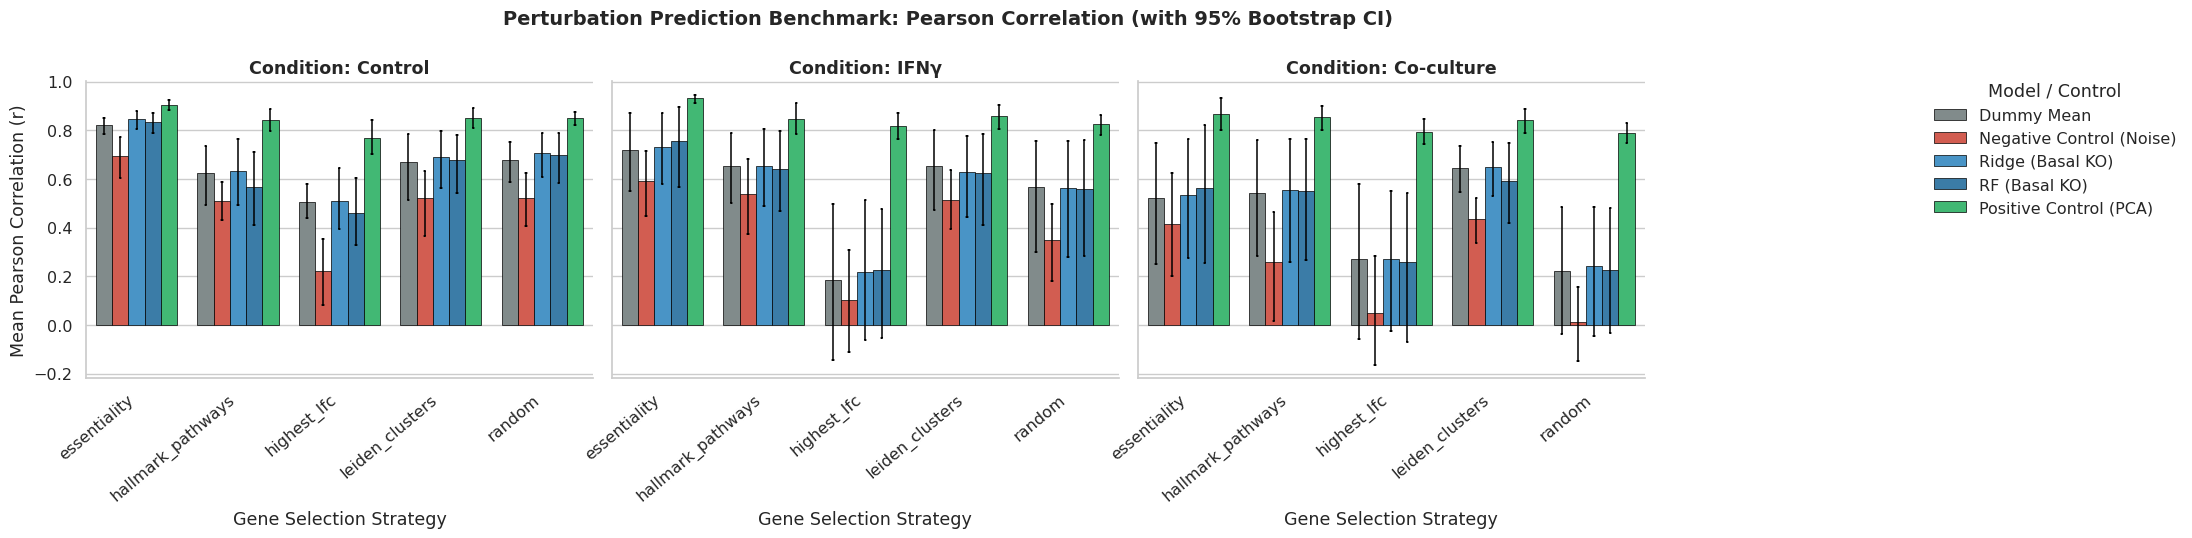

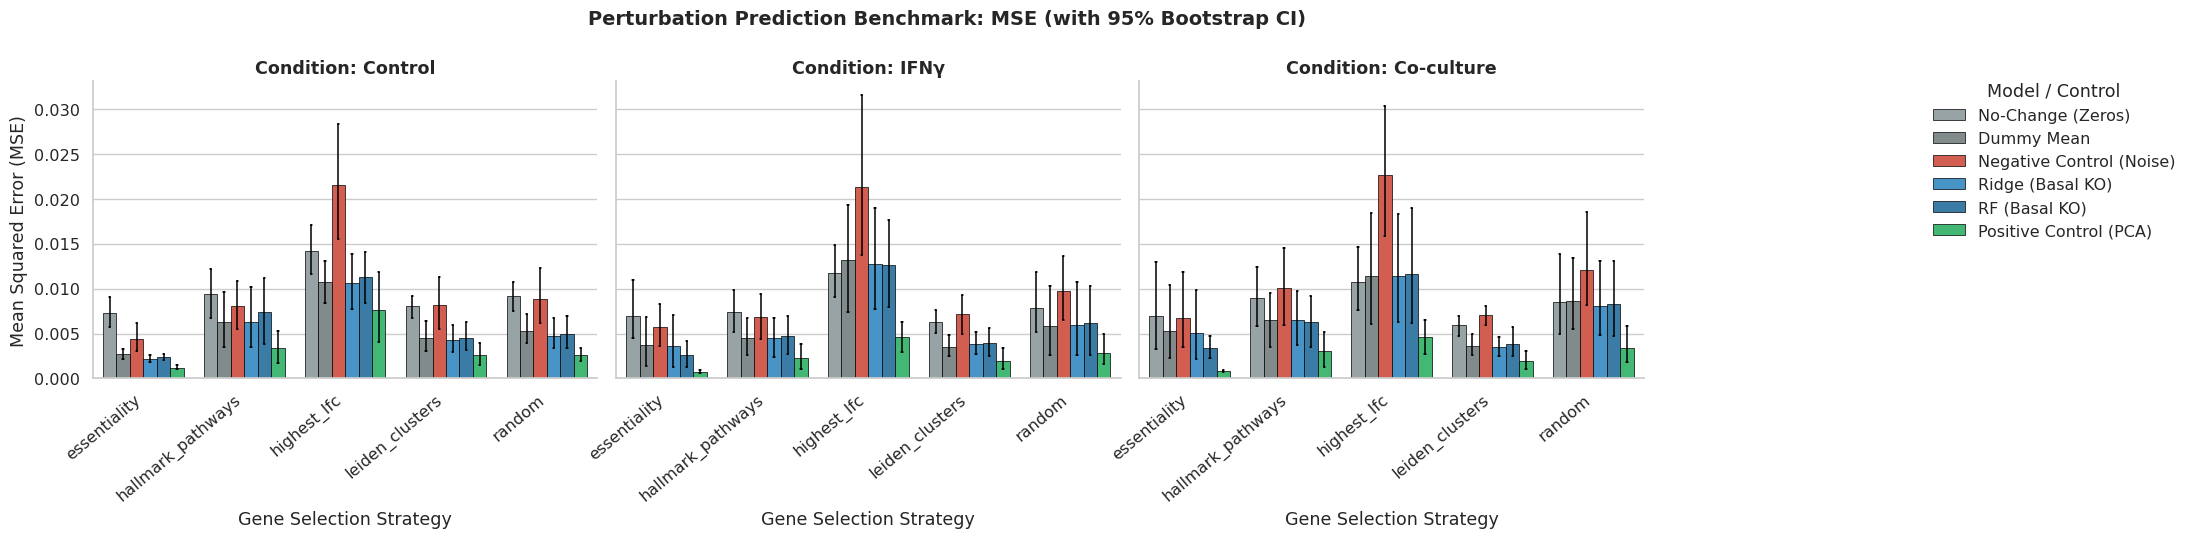

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = [
    'No-Change (Zeros)',
    'Dummy Mean',
    'Negative Control (Noise)',
    'Ridge (Basal KO)',
    'RF (Basal KO)',
    'Positive Control (PCA)'
]

custom_palette = {
    'No-Change (Zeros)': '#95a5a6',         # gray
    'Dummy Mean': '#7f8c8d',                # gray
    'Negative Control (Noise)': '#e74c3c',  # red
    'Ridge (Basal KO)': '#3498db',          # blue
    'RF (Basal KO)': '#2980b9',             # blue
    'Positive Control (PCA)': '#2ecc71'     # green
}

sns.set_theme(style='whitegrid', font_scale=1.05)

# r plot
g1 = sns.catplot(
    data=df_all_results.dropna(subset=['Pearson_r']),
    x='Strategy',
    y='Pearson_r',
    hue='Model',
    hue_order=[m for m in model_order if m != 'No-Change (Zeros)'],
    col='Condition',
    kind='bar',
    errorbar=('ci', 95),  
    capsize=0.08,         
    err_kws={'linewidth': 1.1, 'color': 'black'},
    palette=custom_palette,
    height=4.5,
    aspect=1.25,
    edgecolor='black',
    linewidth=0.5
)

g1.set_axis_labels('Gene Selection Strategy', 'Mean Pearson Correlation (r)')
g1.set_titles(col_template='Condition: {col_name}', weight='bold')
g1.set_xticklabels(rotation=40, ha='right')
g1.figure.subplots_adjust(top=0.82)
g1.figure.suptitle('Perturbation Prediction Benchmark: Pearson Correlation (with 95% Bootstrap CI)', fontsize=14, weight='bold')
sns.move_legend(g1, "upper left", bbox_to_anchor=(1.0, 0.85), title='Model / Control')
plt.show()


# 2. MSE Plot 

g2 = sns.catplot(
    data=df_all_results,
    x='Strategy',
    y='MSE',
    hue='Model',
    hue_order=model_order,
    col='Condition',
    kind='bar',
    errorbar=('ci', 95),  
    capsize=0.08,
    err_kws={'linewidth': 1.1, 'color': 'black'},
    palette=custom_palette,
    height=4.5,
    aspect=1.25,
    edgecolor='black',
    linewidth=0.5
)

g2.set_axis_labels('Gene Selection Strategy', 'Mean Squared Error (MSE)')
g2.set_titles(col_template='Condition: {col_name}', weight='bold')
g2.set_xticklabels(rotation=40, ha='right')
g2.figure.subplots_adjust(top=0.82)
g2.figure.suptitle('Perturbation Prediction Benchmark: MSE (with 95% Bootstrap CI)', fontsize=14, weight='bold')
sns.move_legend(g2, "upper left", bbox_to_anchor=(1.0, 0.85), title='Model / Control')
plt.show()